## 1 · Imports

In [1]:
from anndata import AnnData
from typing import Optional

# Libraries
import anndata as ad
#import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.pyplot import rc_context
from scipy.stats import median_abs_deviation

from functools import partial
import altair as alt
import seaborn as sns
import decoupler as dc
from scipy.sparse import csr_matrix
import os
from pathlib import Path

import mudata as mu
import scanpy as sc
import scirpy as ir
import altair as alt
alt.data_transformers.enable("vegafusion")

import anndata as ad
import numpy as np
import palantir

import numpy as np
import scipy.sparse as sp


In [2]:
import matplotlib.pyplot as plt

In [3]:
import muon as mu
from muon import MuData

2026-06-01 10:49:06.652478: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-01 10:49:06.706116: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz
#from sccoda.util import comp_ana as mod

## 2 · Data Loading

Load mudata

In [5]:
mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_mudata.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adop

In [19]:
mask = mdata["gex"].obs["cell_annotation_05"] != "Cycling"

mdata_without_cycling = mdata[mask, :].copy()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [20]:
mdata

MuData object with n_obs × n_vars = 72592 × 17590
  3 modalities
    gex:	72592 x 17581
      obs:	'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    adt:	56305 x 9
      obs:	'sample_id', 'year', 'tissue', 'treatment', 'received_ici'
    airr:	56305 x 0
      obs:	'sample_id'
      obsm:	'airr'

In [21]:
mdata_without_cycling

MuData object with n_obs × n_vars = 70414 × 17590
  3 modalities
    gex:	70414 x 17581
      obs:	'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    adt:	54564 x 9
      obs:	'sample_id', 'year', 'tissue', 'treatment', 'received_ici'
    airr:	54564 x 0
      obs:	'sample_id'
      obsm:	'airr'

In [7]:
rename_dict = {
    "10mix_ICI1": "ctrl1",
    "10mix_ICI2": "ctrl2",
    "11mix_ICI1": "effector1",
    "11mix_ICI2": "effector2",
    "GF_ICI1": "GF_noici1",
    "GF_ICI2": "GF_noici2",
    "GF_ICI1_plus": "GF1",
    "GF_ICI2_plus": "GF2"
}

mdata["gex"].obs["sample_id"] = (
    mdata["gex"].obs["sample_id"]
    .replace(rename_dict)
)

/tmp/ipykernel_760486/2077462208.py:14: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace(rename_dict)


<Axes: title={'center': 'cell_annotation_05'}, xlabel='UMAP1', ylabel='UMAP2'>

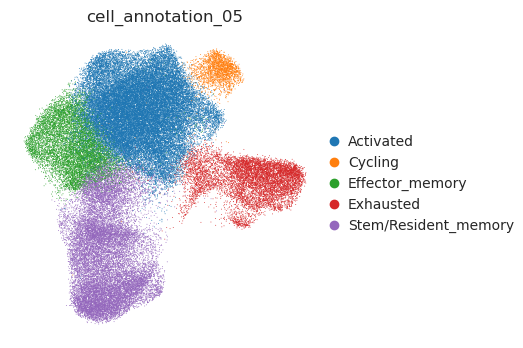

In [8]:
sc.pl.umap(
    mdata["gex"],
    color=["cell_annotation_05"],
    cmap="Reds",
    vmin=0,
    vmax="p99",
    sort_order=False,
    show=False, frameon=False
)

<Axes: title={'center': 'sample_id'}, xlabel='UMAP1', ylabel='UMAP2'>

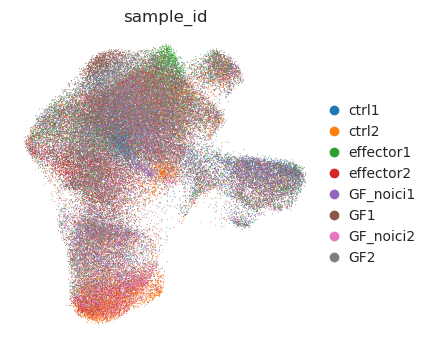

In [9]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    cmap="Reds",
    vmin=0,
    vmax="p99",
    sort_order=False,
    show=False, frameon=False
)

## 2 · Compositional - with cycling 


In [10]:
sample_col = "sample_id"
cluster_col = "cell_annotation_05"   # or "rna_leiden", "gex03"
condition_col = "group4"

In [11]:
cov_df = (
    mdata["gex"].obs[[sample_col, condition_col, "batch_id"]]
    .drop_duplicates()
    .set_index(sample_col)
)

cov_df

,group4,batch_id
sample_id,,
ctrl1,ctrl,ICI1
ctrl2,ctrl,ICI2
effector1,effector,ICI1
effector2,effector,ICI2
GF_noici1,GF_noici,ICI1
GF_noici2,GF_noici,ICI2
GF1,GF,ICI1
GF2,GF,ICI2


In [12]:
cov_df = (
    mdata["gex"].obs[[sample_col, condition_col]]
    .drop_duplicates()
    .set_index(sample_col)
)

In [13]:
sccoda_data = dat.from_scanpy(
    mdata["gex"],
    cell_type_identifier=cluster_col,
    sample_identifier=sample_col,
    covariate_df=cov_df
)

sccoda_data

AnnData object with n_obs × n_vars = 8 × 5
    obs: 'group4'
    var: 'n_cells'

In [14]:
import pandas as pd

condition_col = "group4"

desired_order = [
    "GF_noici",
    "GF",
    "ctrl",
    "effector"
]

# Set ordered categories
sccoda_data.obs[condition_col] = pd.Categorical(
    sccoda_data.obs[condition_col],
    categories=desired_order,
    ordered=True
)

# Optional: sort rows by category order
sccoda_data.obs = sccoda_data.obs.sort_values(condition_col)

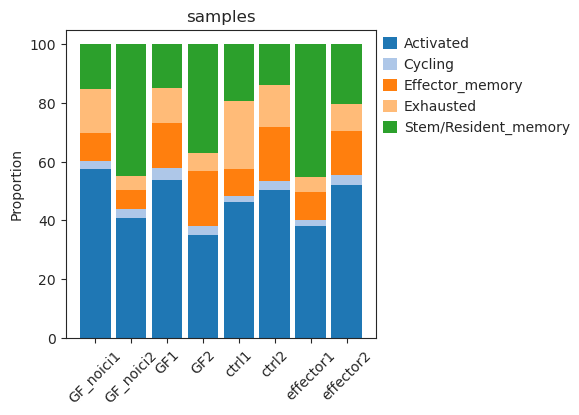

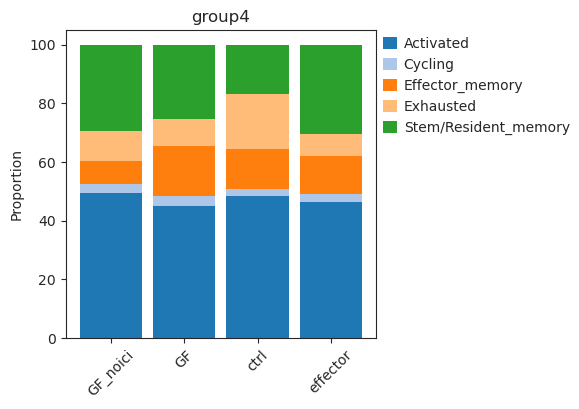

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/seaborn/axisgrid.py:85

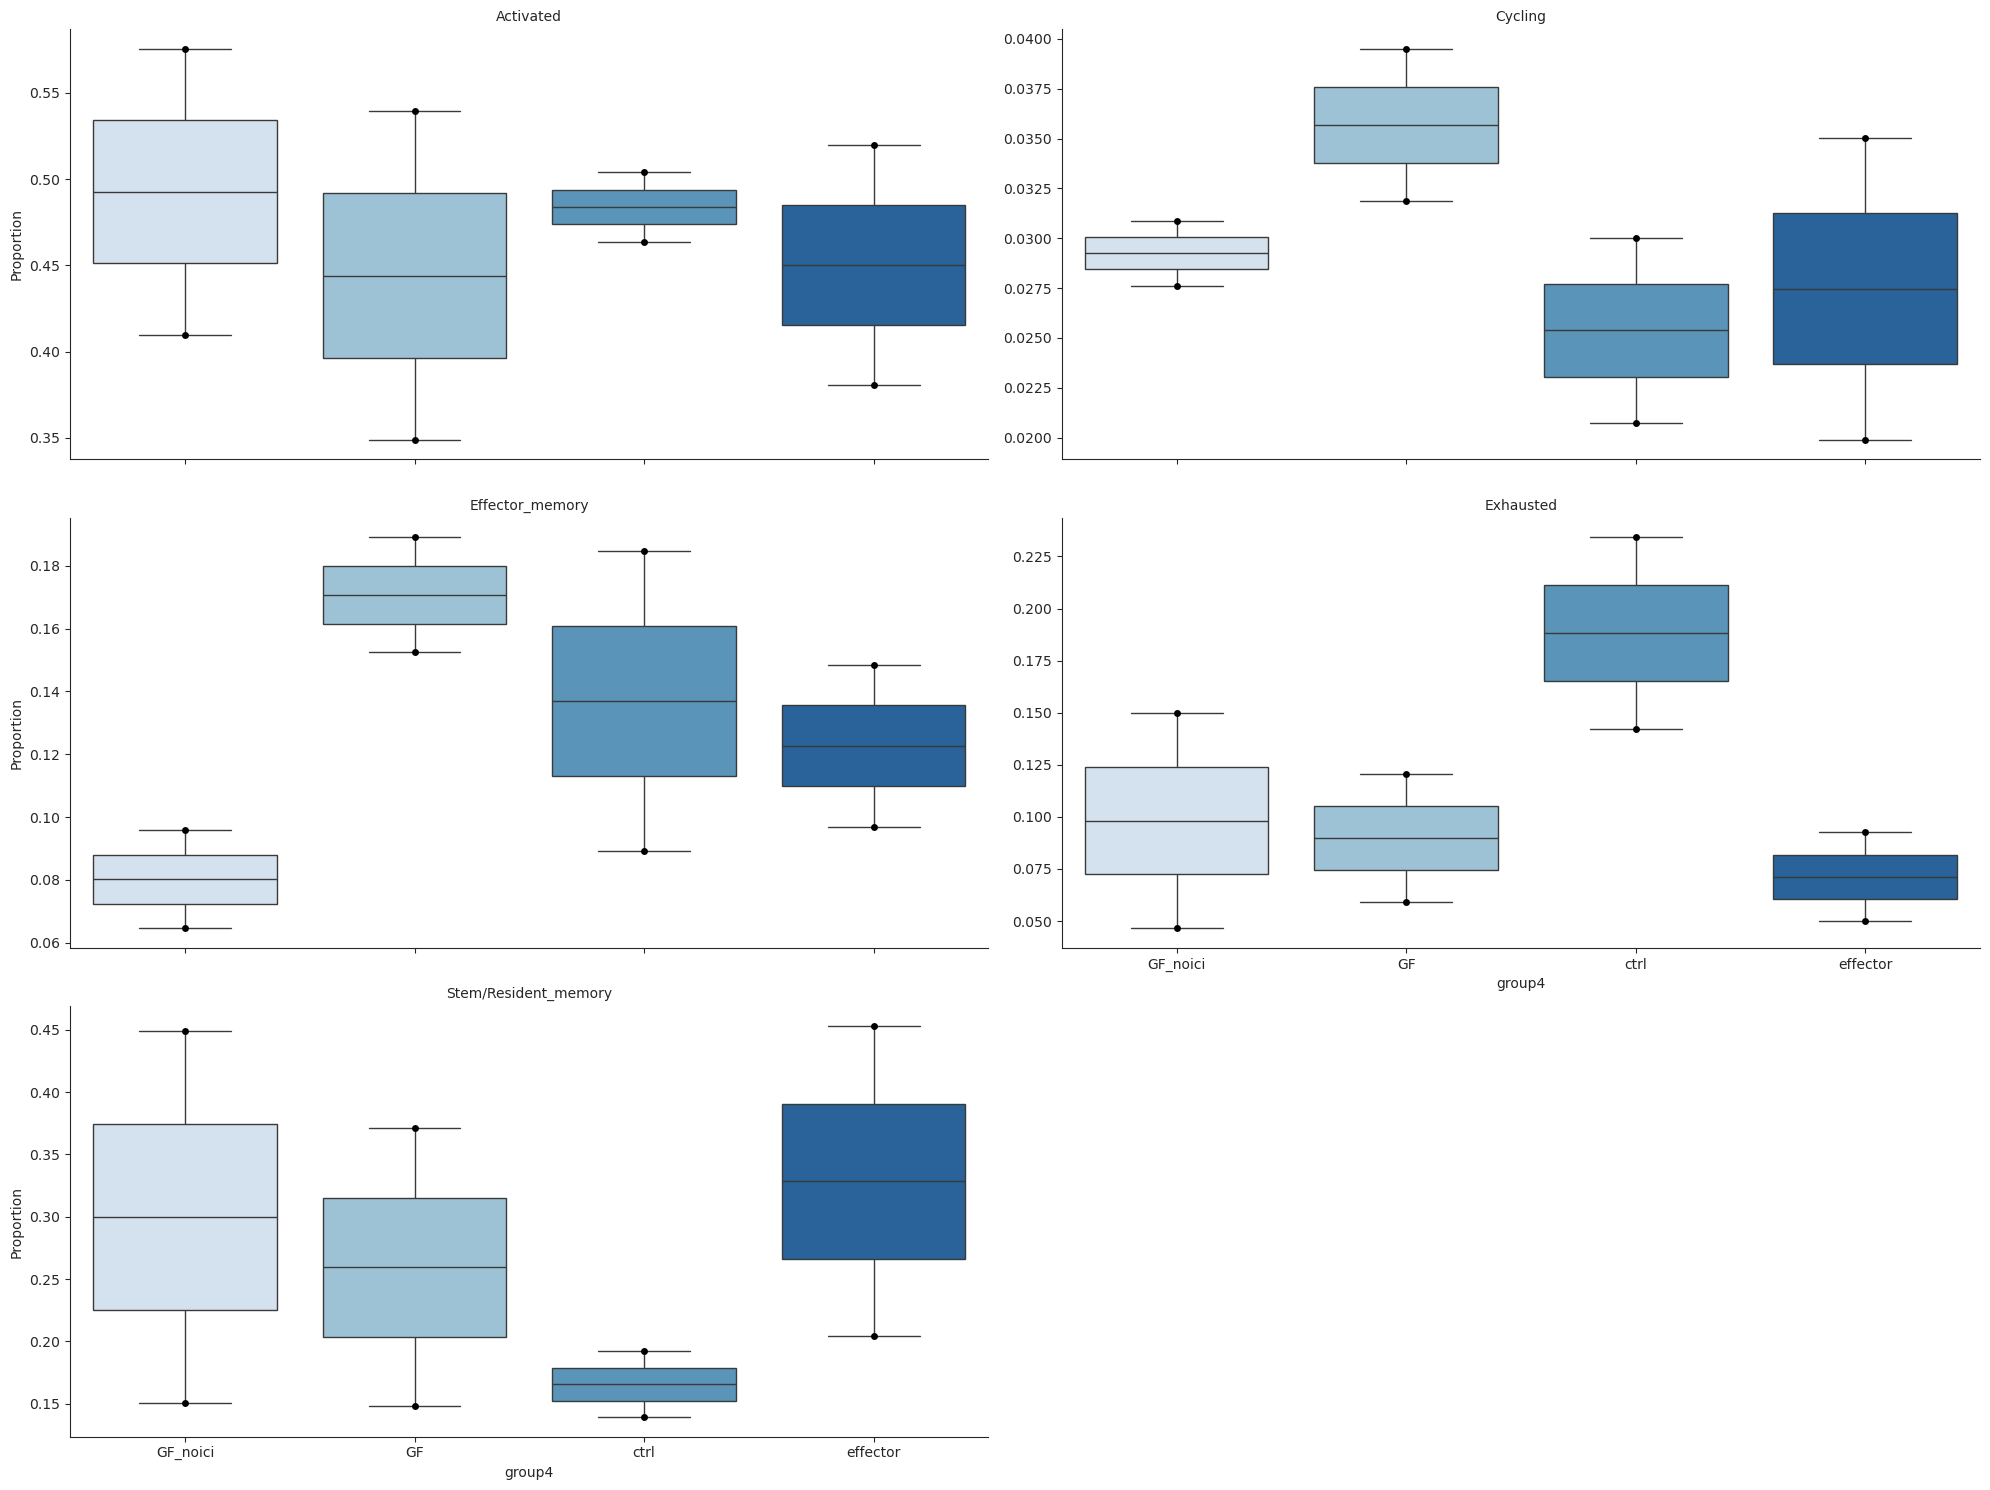

In [15]:
viz.stacked_barplot(sccoda_data, feature_name="samples")
plt.show()

viz.stacked_barplot(sccoda_data, feature_name=condition_col)
plt.show()

viz.boxplots(
    sccoda_data,
    feature_name=condition_col,
    plot_facets=True,
    y_scale="relative",
    add_dots=True
)
plt.show()

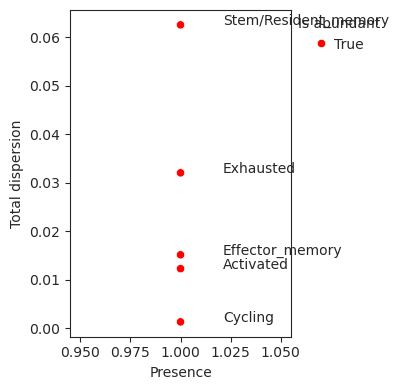

In [16]:
viz.rel_abundance_dispersion_plot(
    data=sccoda_data,
    abundant_threshold=0.9
)
plt.show()

## 3 · Compositional - without cycling 


In [22]:
sample_col = "sample_id"
cluster_col = "cell_annotation_05"   # or "rna_leiden", "gex03"
condition_col = "group4"

In [23]:
cov_df = (
    mdata_without_cycling["gex"].obs[[sample_col, condition_col, "batch_id"]]
    .drop_duplicates()
    .set_index(sample_col)
)

cov_df

,group4,batch_id
sample_id,,
ctrl1,ctrl,ICI1
ctrl2,ctrl,ICI2
effector1,effector,ICI1
effector2,effector,ICI2
GF_noici1,GF_noici,ICI1
GF_noici2,GF_noici,ICI2
GF1,GF,ICI1
GF2,GF,ICI2


In [24]:
cov_df = (
    mdata_without_cycling["gex"].obs[[sample_col, condition_col]]
    .drop_duplicates()
    .set_index(sample_col)
)

In [25]:
sccoda_data = dat.from_scanpy(
    mdata_without_cycling["gex"],
    cell_type_identifier=cluster_col,
    sample_identifier=sample_col,
    covariate_df=cov_df
)

sccoda_data

AnnData object with n_obs × n_vars = 8 × 4
    obs: 'group4'
    var: 'n_cells'

In [26]:
import pandas as pd

condition_col = "group4"

desired_order = [
    "GF_noici",
    "GF",
    "ctrl",
    "effector"
]

# Set ordered categories
sccoda_data.obs[condition_col] = pd.Categorical(
    sccoda_data.obs[condition_col],
    categories=desired_order,
    ordered=True
)

# Optional: sort rows by category order
sccoda_data.obs = sccoda_data.obs.sort_values(condition_col)

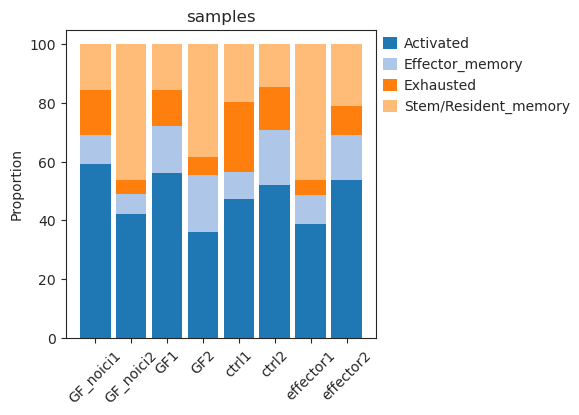

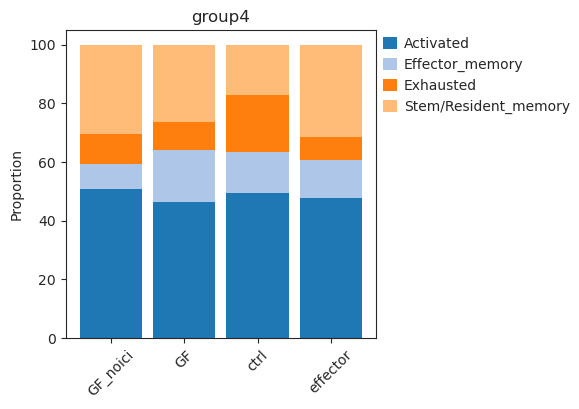

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/seaborn/axisgrid.py:85

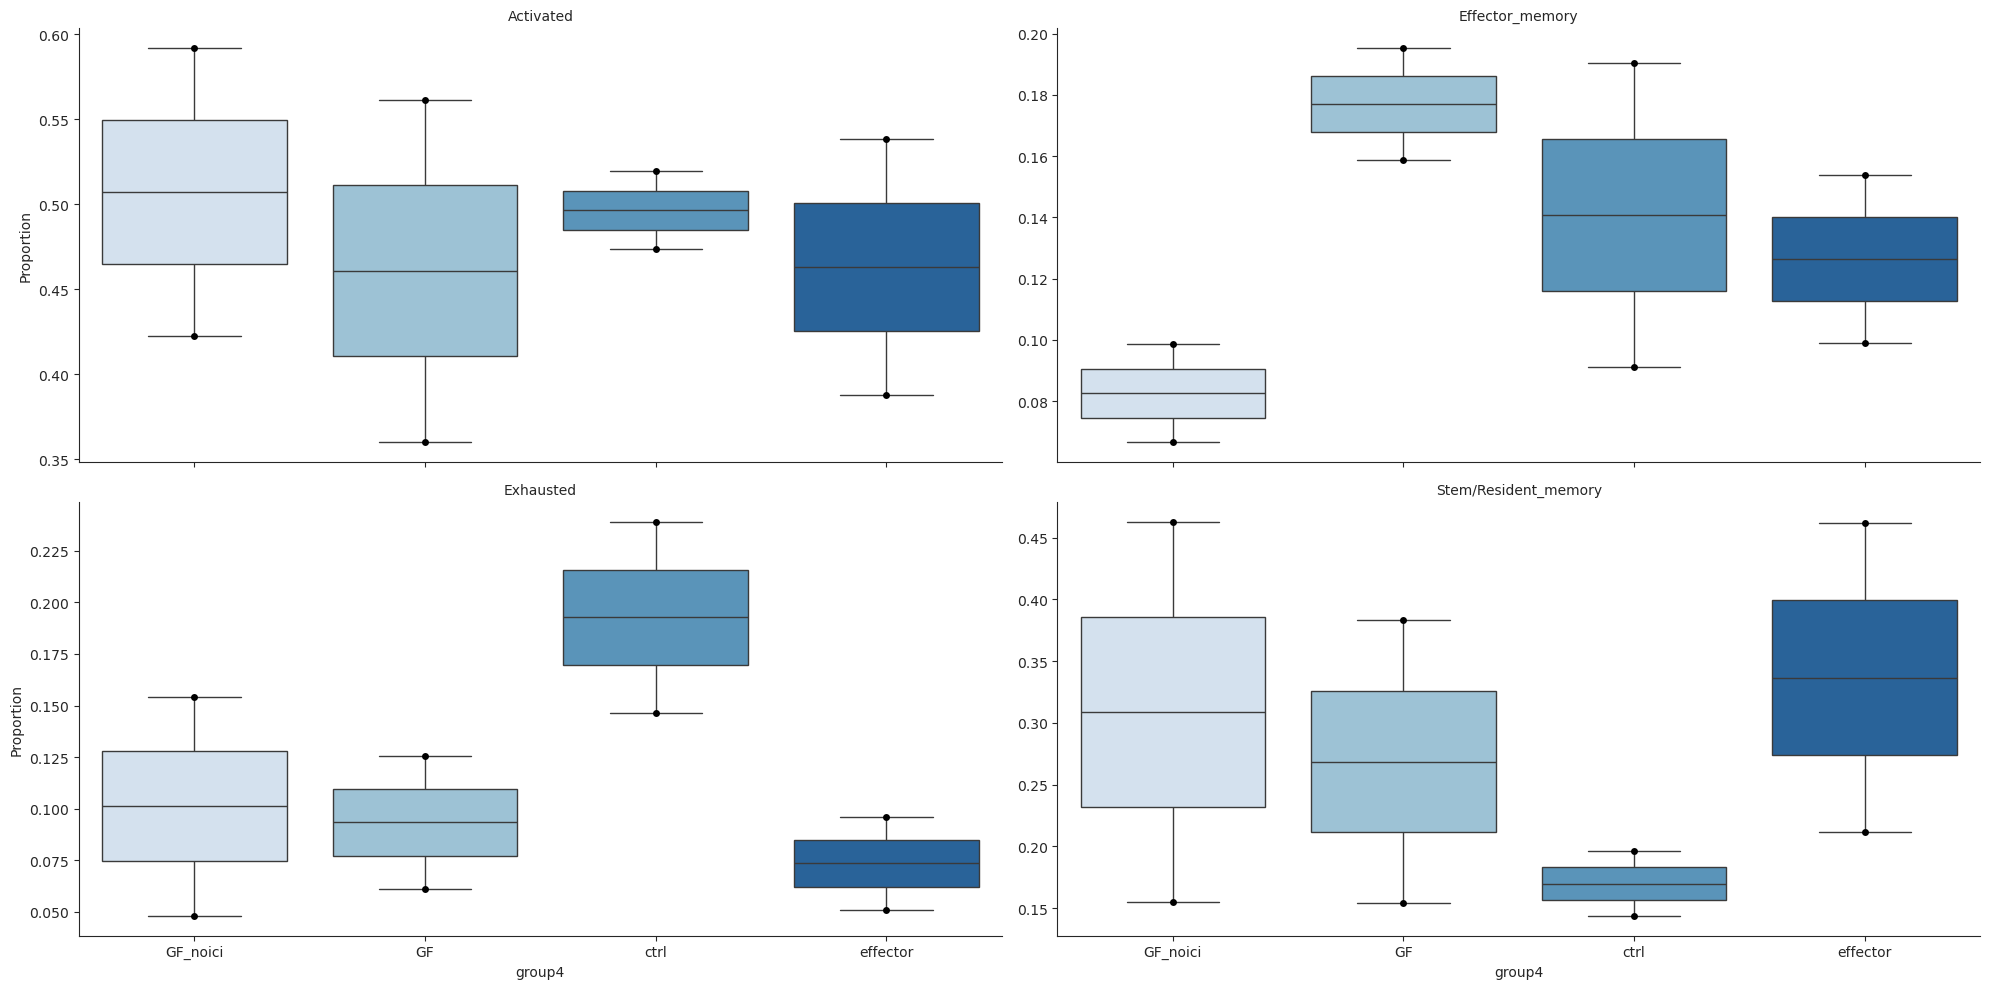

In [27]:
viz.stacked_barplot(sccoda_data, feature_name="samples")
plt.show()

viz.stacked_barplot(sccoda_data, feature_name=condition_col)
plt.show()

viz.boxplots(
    sccoda_data,
    feature_name=condition_col,
    plot_facets=True,
    y_scale="relative",
    add_dots=True
)
plt.show()

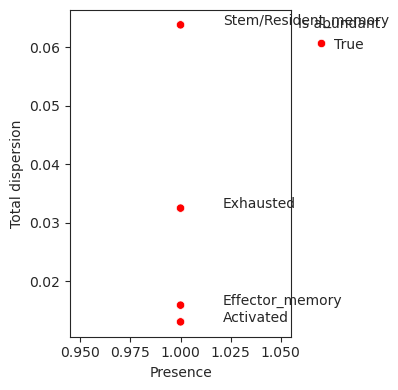

In [28]:
viz.rel_abundance_dispersion_plot(
    data=sccoda_data,
    abundant_threshold=0.9
)
plt.show()